# Sparse Matrix Support with rSVD

In many real-world applications—such as **Recommender Systems** (User-Item matrices) or **NLP** (Term-Document matrices)—data is naturally **sparse**. This means the matrix is mostly filled with zeros, with only a few non-zero entries.

Storing these matrices in a standard "dense" format (NumPy array) is inefficient and often causes **Out-Of-Memory (OOM)** errors.

**randomized-svd** supports `scipy.sparse` matrices natively. This allows you to:

1. **Save RAM:** Store massive matrices efficiently.
2. **Boost Speed:** The random projection step () skips operations on zero elements, resulting in massive speedups.

In [6]:
import time
import numpy as np
import scipy
import scipy.sparse as sp
import matplotlib.pyplot as plt
from randomized_svd import rsvd

print(f"NumPy Version: {np.__version__}")
print(f"SciPy Version: {scipy.__version__}")

NumPy Version: 2.4.0
SciPy Version: 1.16.3


## 1. Sanity Check: Dense vs Sparse Consistency

First, let's verify that passing a Sparse matrix yields the exact same mathematical result as passing a Dense matrix.

In [7]:
# 1. Generate a small random matrix
m, n = 1000, 500
t = 10
np.random.seed(42)

# Create a dense matrix with many zeros (simulated sparsity)
X_dense = np.random.randn(m, n)
X_dense[np.abs(X_dense) < 1.0] = 0  # Zero out ~68% of data

# Convert to SciPy CSR (Compressed Sparse Row) format
X_sparse = sp.csr_matrix(X_dense)

print(f"Matrix Shape: {X_dense.shape}")
print(f"Non-zero elements: {X_sparse.nnz} ({X_sparse.nnz / (m*n):.1%} density)")

# 2. Compute rSVD on Dense input
# We fix the internal seed of numpy to ensure the random projection matrix P is identical
np.random.seed(99) 
U_dense, S_dense, Vt_dense = rsvd(X_dense, t=t)

# 3. Compute rSVD on Sparse input
np.random.seed(99) 
U_sparse, S_sparse, Vt_sparse = rsvd(X_sparse, t=t)

# 4. Compare Singular Values
print("\n--- Singular Values Comparison ---")
print(f"Dense:  {S_dense[:5]}")
print(f"Sparse: {S_sparse[:5]}")

is_close = np.allclose(S_dense, S_sparse, atol=1e-10)
print(f"\nAre results identical? {'✅ YES' if is_close else '❌ NO'}")

Matrix Shape: (1000, 500)
Non-zero elements: 158697 (31.7% density)

--- Singular Values Comparison ---
Dense:  [[38.13495389  0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.         37.46814686  0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.         37.29819737  0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.         36.91516849  0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.         36.47326818  0.
   0.          0.          0.          0.        ]]
Sparse: [[38.13495389  0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.         37.46814686  0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.         37.29819737  0.          0.       

## 2. Performance Benchmark: The "Netflix" Scenario

Let's simulate a larger dataset, typical of a recommender system (Users  Movies).
We will create a **5000  5000** matrix with **1% density** (99% zeros).

We compare the execution time of `rsvd` when handling the input as Dense vs Sparse.

In [8]:
# Configuration
N = 5000        # Matrix size (N x N)
density = 0.01  # 1% density
target_rank = 50

print(f"Generating {N}x{N} matrix with {density:.1%} density...")

# Generate Sparse Matrix directly
# (Generating a dense 5k x 5k would require 200MB, acceptable for this demo, 
# but imagine N=50k -> 20GB RAM!)
np.random.seed(42)
X_sparse = sp.rand(N, N, density=density, format='csr')

# Create a Dense copy for benchmarking
X_dense = X_sparse.toarray()

print(f"Data generated. Starting Benchmark for rank k={target_rank}...\n")

# --- Benchmark Dense ---
start = time.perf_counter()
rsvd(X_dense, t=target_rank)
end = time.perf_counter()
time_dense = end - start
print(f"Dense Input Time:  {time_dense:.4f} seconds")

# --- Benchmark Sparse ---
start = time.perf_counter()
rsvd(X_sparse, t=target_rank)
end = time.perf_counter()
time_sparse = end - start
print(f"Sparse Input Time: {time_sparse:.4f} seconds")

# --- Results ---
speedup = time_dense / time_sparse
print(f"\n🚀 Speedup: {speedup:.1f}x faster with Sparse Input")

Generating 5000x5000 matrix with 1.0% density...
Data generated. Starting Benchmark for rank k=50...

Dense Input Time:  0.0729 seconds
Sparse Input Time: 0.0357 seconds

🚀 Speedup: 2.0x faster with Sparse Input


## 3. Visualization

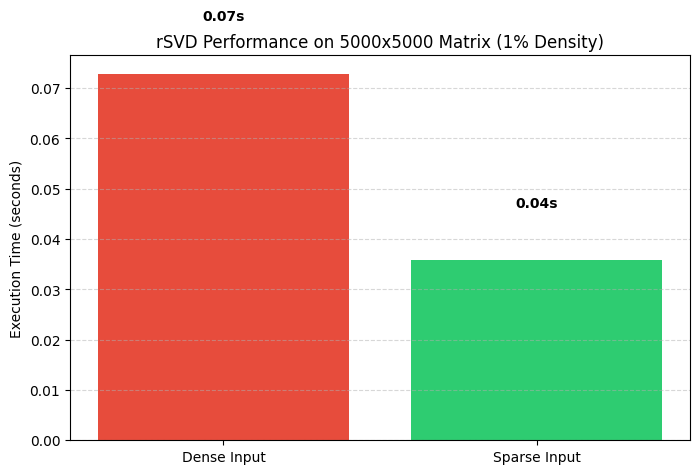

In [9]:
methods = ['Dense Input', 'Sparse Input']
times = [time_dense, time_sparse]

plt.figure(figsize=(8, 5))
bars = plt.bar(methods, times, color=['#e74c3c', '#2ecc71'])

plt.ylabel('Execution Time (seconds)')
plt.title(f'rSVD Performance on {N}x{N} Matrix (1% Density)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}s', ha='center', va='bottom', fontweight='bold')

plt.show()